In [176]:
import pandas as pd
from NACE_helper import NACE_helper
import matplotlib.pyplot as plt

In [177]:
ds_2  = pd.read_csv("projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_2/reports_subset_from_full_data_2_overview.csv")
ds_3  = pd.read_csv("projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_3/reports_subset_from_full_data_3_overview.csv")

In [178]:
ds_3.loc[:,"NACE_lvl_3"] = ds_3["NACE"].apply(lambda x: NACE_helper.get_all_level(x)[3])

In [179]:
all_classes = ['01.5',
 '01.6',
 '03.1',
 '03.2',
 '21.1',
 '21.2',
 '26.1',
 '26.6',
 '64.1',
 '64.3',
 '64.9',
 '64.2',
 '66.1',
 '66.2',
 '66.3',
 '41.1',
 '41.2',
 '42.1',
 '42.2',
 '42.9',
 '58.1',
 '58.2',
 '61.1',
 '61.2',
 '77.1',
 '77.3',
 '81.3']
len(all_classes)

27

In [ ]:
ds_2_relevant = ds_3[ds_3['NACE_lvl_3'].isin(all_classes)]
ds_2_relevant

,Unnamed: 0,Symbol,Name,Company is Active,Company Founded Date,Country of Primary Listing Iso3,CUSIP,Date Of First Trade,Entity Country HQ,Entity Credit Parent,...,Primary Equity Listing,Proper Name,Public Company,Region Ticker,Sec is Primary Issue,Sec Type,SEDOL,NACE_Letter,Report,NACE_lvl_3
2,2,ID1000167901,PT Cilacap Samudera Fishing Industry Tbk,0,1999.0,IDN,Y129H6108,20220527.0,IDN,@NA,...,BMBMZG,PT Cilacap Samudera Fishing Industry Tbk,1.0,ASHA-ID,0,SHARE,BMBMZG9,A,PT Cilacap Samudera Fishing Industry Tbk3.pdf,03.1
10,10,ARP331091024,Cresud SA,1,1936.0,ARG,P3311R127,19850102.0,ARG,001MSF-E,...,223338,Cresud SA,1.0,CRES-AR,1,SHARE,2233387,A,Cresud SA1.pdf,01.6
11,11,LU0611262873,KSG Agro SA,1,2010.0,POL,L5903L107,20110505.0,UKR,0BRK63-E,...,B42XFB,KSG Agro SA,1.0,KSG-PL,1,SHARE,B42XFB0,A,KSG Agro SA1.pdf,01.5
15,15,LK0297N00008,Kahawatte Plantations PLC,1,1992.0,LKA,Y44954108,19990610.0,LKA,081QN4-E,...,613927,Kahawatte Plantations PLC,1.0,KAHA.N0000-LK,1,SHARE,6139276,A,Kahawatte Plantations PLC1.pdf,01.6
16,16,INE594O01015,R J Bio-Tech Ltd.,0,2005.0,IND,Y73126107,20130925.0,IND,@NA,...,BF49P8,R J Bio-Tech Ltd.,1.0,536456-IN,0,SHARE,BF49P80,A,R J Bio-Tech Ltd.2.pdf,01.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,659,INE359A01012,Escorts Finance Limited,1,1987.0,IND,Y2296Y115,19981223.0,IND,@NA,...,616370,Escorts Finance Limited,1.0,511716-IN,1,SHARE,6163703,N,Escorts Finance Limited2.pdf,77.3
672,672,AU000000MMS5,Mcmillan Shakespeare Limited,1,1988.0,AUS,Q58998107,20040315.0,AUS,006FG8-E,...,B00G1Q,Mcmillan Shakespeare Limited,1.0,MMS-AU,1,SHARE,B00G1Q0,N,Mcmillan Shakespeare Limited1.pdf,77.1
682,682,TRAFFKRL91P0,QNB Finans Finansal Kiralama A.S.,1,1990.0,TUR,M4578P104,19940221.0,TUR,062BGT-E,...,B03MSM,QNB Finans Finansal Kiralama A.S.,1.0,QNBFL.E-TR,1,SHARE,B03MSM0,N,QNB Finans Finansal Kiralama A.S.1.pdf,77.3
687,687,US10948C1071,"BrightView Holdings, Inc.",1,2013.0,USA,10948C107,20180628.0,USA,0GL2M1-E,...,10948C10,"BrightView Holdings, Inc.",1.0,BV-US,1,SHARE,BG0ZML1,N,"BrightView Holdings, Inc.1.pdf",81.3


In [ ]:
ds_2_relevant.groupby('NACE_lvl_3').size()

NACE_lvl_3
01.5     2
01.6     4
03.1     1
03.2     3
21.1     2
21.2     3
26.1     3
41.1     5
41.2    15
42.1     5
42.2    10
42.9     5
58.1     1
58.2    22
61.1     1
61.2     3
64.1    10
64.2     1
64.9    19
66.1     7
66.2     1
66.3     4
77.1     1
77.3     5
81.3     2
dtype: int64

<Axes: ylabel='NACE_lvl_3'>

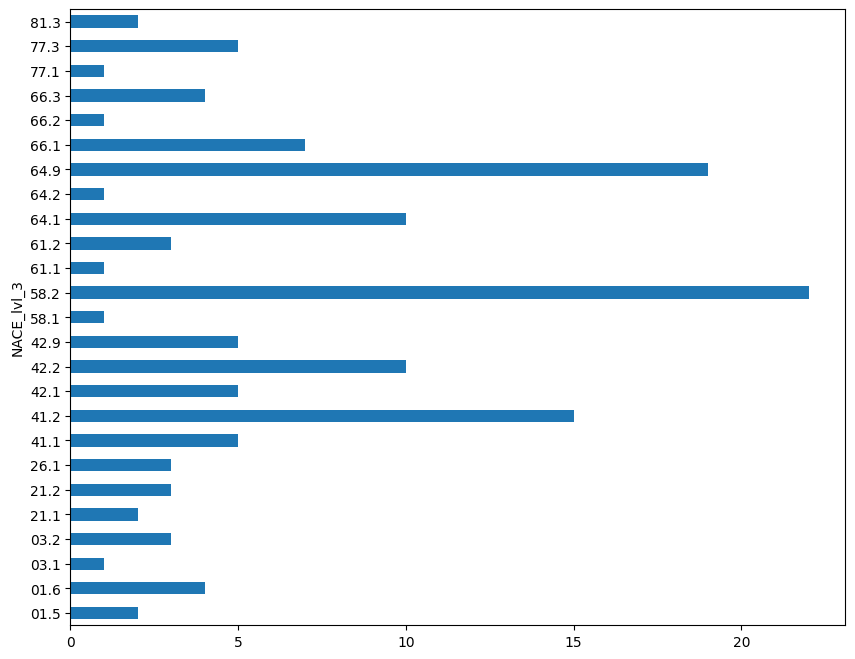

In [ ]:
ds_2_relevant.groupby('NACE_lvl_3').size().plot(kind='barh', figsize=(10,8))

In [ ]:
ds_2_relevant.to_csv("projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_3/reports_subset_from_full_data_3_for_backtracking.csv", index=False)

In [ ]:
import shutil

for i, row in ds_2_relevant.iterrows():
    src = f"projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_3/PDFs/{row['Report']}"
    dst = f"projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_3/PDFs_for_backtracking/{row['Report']}"
    shutil.copyfile(src, dst)

In [170]:
test_df = pd.read_csv("projects/nace_classification/nace_report_topic_analysis/data/training_data/approach_2/dataset__reports_subset_from_full_data_2_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_3__2nd_approach__nace_level_3__cos_thres_0.35/test_data.csv")

## DS 2

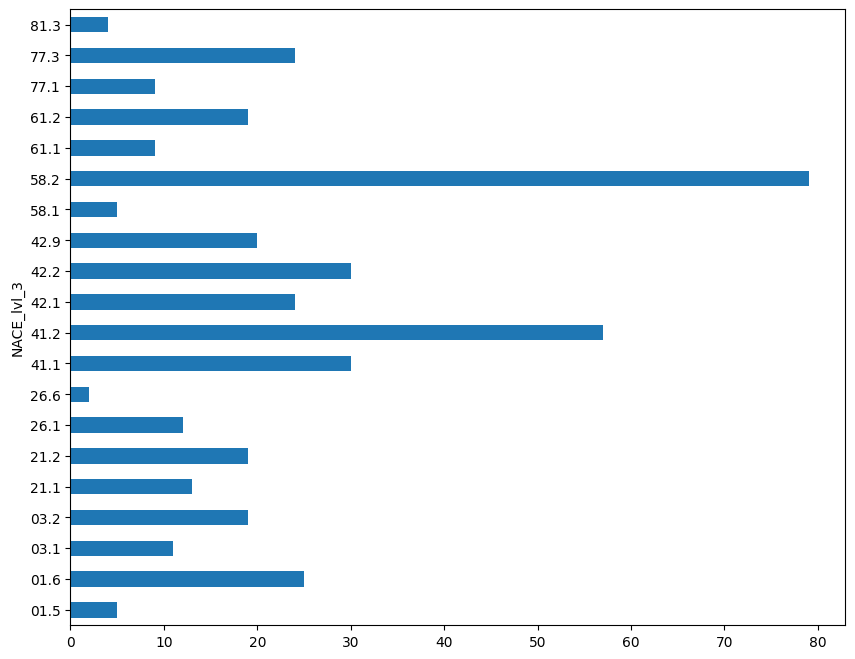

In [187]:
ds_2.loc[:,"NACE_lvl_3"] = ds_2["NACE"].apply(lambda x: NACE_helper.get_all_level(x)[3])
all_classes = ['01.5',
 '01.6',
 '03.1',
 '03.2',
 '21.1',
 '21.2',
 '26.1',
 '26.6',
# '64.1',
#  '64.3',
#  '64.9',
#  '64.2',
#  '66.1',
#  '66.2',
#  '66.3',
 '41.1',
 '41.2',
 '42.1',
 '42.2',
 '42.9',
 '58.1',
 '58.2',
 '61.1',
 '61.2',
 '77.1',
 '77.3',
 '81.3']

ds_2_relevant = ds_2[ds_2['NACE_lvl_3'].isin(all_classes)]
ds_2_relevant
ds_2_relevant.groupby('NACE_lvl_3').size()
ds_2_relevant.groupby('NACE_lvl_3').size().plot(kind='barh', figsize=(10,8))
ds_2_relevant.to_csv("projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_2/reports_subset_from_full_data_2_for_backtracking_no_finance.csv", index=False)

In [188]:
len(ds_2_relevant)

416

In [ ]:
import shutil

for i, row in ds_2_relevant.iterrows():
    src = f"projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_2/PDFs/{row['Report']}"
    dst = f"projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_2/
    /{row['Report']}"
    shutil.copyfile(src, dst)

In [203]:
df_2 = pd.read_csv("projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_2/reports_subset_from_full_data_2_for_backtracking.csv", sep=",")
df_3 = pd.read_csv("projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_3/reports_subset_from_full_data_3_for_backtracking.csv", sep=";")

In [206]:
set(df_2["Name"]) & set(df_3["Name"])

{'AcuityAds Holdings Inc',
 'Alerus Financial Corporation',
 'Amanat Holding PJSC',
 'Analog Devices, Inc.',
 'Ares Acquisition Corp.',
 'Athena Constructions Ltd.',
 'Aurum Proptech Limited',
 'BrightView Holdings, Inc.',
 'Budimex SA',
 'CF Acquisition Corp. IV',
 'Cancer Capital Corp.',
 'China Energy Engineering Corp. Ltd.',
 'Cizzle Biotechnology Holdings PLC',
 'Clean Seas Seafood Limited',
 'Continental Holdings Corp.',
 'Cresud SA',
 'Custom Truck One Source Inc',
 'Daiwa Securities Group Inc.',
 'Deutsche Eigenheim Union AG',
 'Eagle Bancorp Montana, Inc.',
 'East West Bancorp, Inc.',
 'Encompass Compliance Corp.',
 'First Heartland Jusan Bank JSC',
 'Frontken Corp. Bhd.',
 'GPP Resources Bhd.',
 'Gensight Biologics SA',
 'Grad d.d.',
 'HaiPhong Construction Joint Stock Corporation No3',
 'Heritage Global Inc.',
 'Hsin Ba Ba Corporation',
 'Hybrid Software Group PLC',
 'KRM22 Plc',
 'KSG Agro SA',
 'Kiniksa Pharmaceuticals Ltd.',
 'Mcmillan Shakespeare Limited',
 'Mirae Asset 

In [218]:
df_1 = pd.read_csv("projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_1/reports_subset_from_full_data_1_overview.csv", sep=",")
df_2 = pd.read_csv("projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_2/reports_subset_from_full_data_2_overview.csv", sep=",")
df_3 = pd.read_csv("projects/nace_classification/nace_report_topic_analysis/data/datasets/reports_subset_from_full_data_3/reports_subset_from_full_data_3_overview.csv", sep=",")

In [219]:
(len(df_1), len(df_2), len(df_3))

(1562, 3287, 893)

In [216]:
len(set(df_2["Name"]) & set(df_3["Name"]))

834

In [220]:
len(set(df_1["Name"]) & set(df_2["Name"]) & set(df_3["Name"]))

0

In [222]:
len(set(df_1["Name"]) & set(df_2["Name"]))

1562

In [ ]:
len(set(df_1["Name"]) & set(df_3["Name"]))

0